Wir arbeiten im Folgenden mit dem USPS (United States Postal Service) Datensatz, der 16x16 Grauwertbilder von handgeschriebenen Ziffern (0-9) enthält.

![title](https://git-disl.github.io/GTDLBench/figures/usps.png)

1.) Laden Sie zunächst die Daten aus der zur verfügbar gestellten Datei. Passen Sie den Pfad entsprechend an.


In [2]:
import h5py
import numpy as np

# load the data
f = h5py.File("C:\\Users\\dhbw\\OneDrive\\Dokumente\\Vorlesung 2025\\data\\usps_data.hdf5",'r+')
trainX = np.array(f.get('trainX'))
trainY = np.array(f.get('trainY'))
testX = np.array(f.get('testX'))
testY = np.array(f.get('testY'))
f.close()


trainX enthält N Trainingsbeispiele (Zeilen) mit p Merkmalen (Anzahl Features):

In [3]:
[N_train, p] = trainX.shape
print(f"Anzahl Trainingsbeispiele: {N_train} mit {p} Features/Merkmalen")

Anzahl Trainingsbeispiele: 10000 mit 256 Features/Merkmalen


Hierbei sind die 256 Features die Grauwerte der 16x16 Pixel der Bilder der Ziffern.

Analog kann man das für testX, die zugehörigen Testbeispiele, abfragen:

In [4]:
# TODO
[N_test, p] = testX.shape
print(f"Anzahl Trainingsbeispiele: {N_test} mit {p} Features/Merkmalen")

Anzahl Trainingsbeispiele: 1000 mit 256 Features/Merkmalen


trainY und testY enthalten die zugehörigen Labels

In [5]:
[N2_train, q1] = trainY.shape
print(f"Anzahl Trainingsdaten-Labels: {N2_train}")
[N2_test, q2] = testY.shape
print(f"Anzahl Testdaten-Labels: {N2_test}")

Anzahl Trainingsdaten-Labels: 10000
Anzahl Testdaten-Labels: 1000


Die gelabeleten Trainingsdaten sind sortiert: Zunächst haben wir 1000 Beispiele für die Ziffer 1, dann 1000 Beispiele für die Ziffer 2, ..., zuletzt für die Ziffern 9 und 0:

In [6]:
print(trainY)

[[1.]
 [1.]
 [1.]
 ...
 [0.]
 [0.]
 [0.]]


2.) Nun betrachten wir ein paar Beispiele. Zunächst visualisieren wir das erste Beispiel für die Klasse 2. Hierzu verwenden wir matpolotlib. 

Mittels reshape machen wir aus dem 1x256 Vektor wieder ein Bild. Transpose sorgt dafür, dass es nicht auf dem Kopf steht.

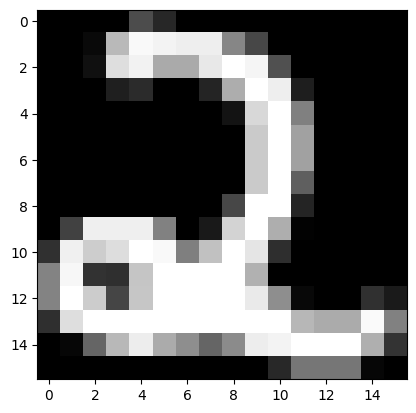

In [7]:
import matplotlib.pyplot as plt

# First sample of number 2
plt.imshow(trainX[1000,:].reshape(16,16).transpose(),cmap='gray')
plt.show()

Wiederholen Sie dies nun für die folgenden Bilder:
* 3. Beispiel für Ziffer 3
* 1. Beispiel für Ziffer 0

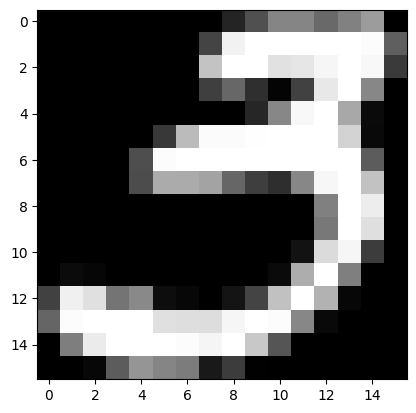

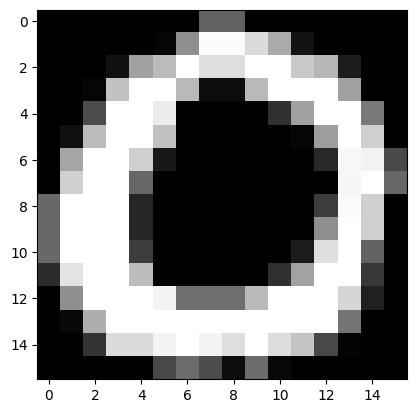

In [8]:
# TODO

# 3rd sample of number 3
plt.imshow(trainX[2002,:].reshape(16,16).transpose(),cmap='gray')
plt.show()

# 1st sample of number 0
plt.imshow(trainX[9000,:].reshape(16,16).transpose(),cmap='gray')
plt.show()

Plotten Sie nun den Mittelwert für jede einzelne Ziffer als Bild. Nutzen Sie den Befehl "where" aus numpy, um die entsprechenden Zeilen zu extrahieren, bevor Sie den Mittelwert (Befehl mean in numpy) bilden und das Bild anschließend reshapen.

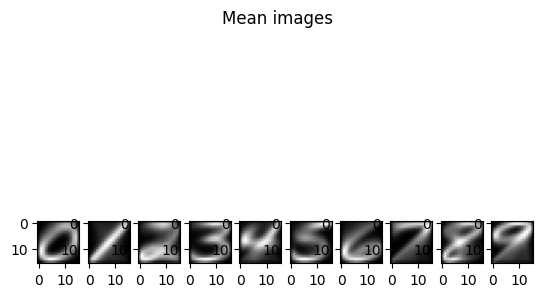

In [9]:
fig, axs = plt.subplots(1,10)
fig.suptitle('Mean images')
for i in range(0,10):

    #todo
    mean_image = np.mean(trainX[np.where(trainY==i)[0], :], axis=0)
    mean_image = mean_image.reshape(16,16).transpose()
    
    axs[i].imshow(mean_image, cmap='gray')
plt.show()

3.) Schreiben Sie nun eine Funktion 

def euclidean_distance_2loops(data1: np.array, data2: np.array)

die die euklidische Distanz zwischen allen Trainingsbildern (-vektoren) und Testbildern (-vektoren) berechnet. Als Eingabe dienen also zwei nd-arrays der Größen N_train x p und N_test x p (N_train ist die Anzahl der Trainingsbeispiele/Samples in data1, N_test ist die Anzahl der Testbeispiele/Samples in data2, p ist die Dimension der Daten/Anzahl der Features). Die Ausgabe ist ein N_train x N_test nd-array mit den paarweisen Distanzen. 

Die Funktion soll jeweils eine Schleife für die Beispiele in data1 und data2 verwenden. 

Machen Sie sich zunächst klar, was ein Eintrag in den nd-arrays data1, data2 und distances bedeutet. Implementieren Sie dann die Methode.
Nützliche Befehle:  sqrt(A), sum, zeros((m, n)), square aus numpy


In [10]:
import numpy as np

# TODO
# def euclidean_distance(data1: np.array, data2: np.array):

def euclidean_distance(data1: np.array, data2: np.array):
    # dimensions
    data1 = np.atleast_2d(data1) # ensure that the input has 2 dimensions, i.e. convert possible (1000,) to (1000,1)
    data2 = np.atleast_2d(data2)    
    [num_samples1, p] = data1.shape
    [num_samples2, p] = data2.shape

    distances = np.zeros((num_samples1, num_samples2))

    for i in range (0, num_samples1):
        for j in range (0, num_samples2):
            distances[i, j] = np.sqrt( np.sum( np.square(data1[i, :] - data2[j,:] ) ) )
    return distances

Testen Sie die Funktion zunächst mit Daten, für die Sie die Lösung einfach auch selbst berechnen können. Skizzieren Sie kurz die Datenpunkte, was sollte herauskommen?

In [11]:
data1 = np.array([[1, 0], [0, 1], [1, 1]])
data2 = np.array([[1, 0], [0, 1]])

distances2 = euclidean_distance(data1, data2)

print(distances2)

[[0.         1.41421356]
 [1.41421356 0.        ]
 [1.         1.        ]]


4.) Betrachten Sie zunächst folgende kNN Implementierung und überlegen Sie sich, was der Klassifikator in den verschiedenen Zeilen tut.

In [12]:
import numpy as np

'''
function that performs a k nearest neighbor classification

input

trainX      N1xp array of N1 training points in p dimensions
trainY      N1x1 array of training point labels (0-9)
testX       N2xp array of N2 test points in p dimensions
k           the number of considered nearest neighbors

output

predictedY  N2x1 array of predicted labels (0-9)

note: this simple code is biased in the sense that lower 
class numbers are favored in case of ties! 
randomization could help here!

'''
def kNN(trainX: np.array, trainY: np.array, testX: np.array, k):
    trainX = np.atleast_2d(trainX)
    testX = np.atleast_2d(testX)
    
    # 01: TODO: prepare result
    predictedY = np.zeros([testX.shape[0], 1])

    # 02: TODO: calculate distance matrix (N1xN2, i.e. each column refers to one test sample)
    dist = euclidean_distance(trainX, testX)
 
    # 03: TODO: we are now interested in the rows (i.e., training points) with the lowest distances to the test samples
    # with argsort, we do not really sort the matrix along the columns but only retrieve the (row) indices where
    # we can find the closest training samples
    # (true sorting could be done by: sorted = np.take_along_axis(dist, indices, axis=0))
    indices = np.argsort(dist, axis=0)
    
    # 04: TODO: loop over test samples, for each test sample i, find the k nearest neighbors:
    for i in range(0, testX.shape[0]):
        # 05: TODO: get first k entries of the i-th column of the indices matrix
        # and access the corresponding entries in the trainY vector
        first_k_indices = indices[0:k, i]
        labels = trainY[first_k_indices, 0]

        # 06: TODO: calculate a histogram over class labels (here we have the labels 0-9) among
        # the labels of the k nearest neighbors
        # 06a: TODO: first find out which class labels there are
        bins = np.unique(np.asarray(labels))
        # 06b: TODO: add 1 bin to ensure that histo treats this correctly (right boundary) and compute the histogram
        bins = np.append(bins, np.max(bins)+1)
        histo = np.histogram(labels, bins)
        # 07: TODO: do kNN classification:
        # argmax returns the index with the highest number of counts
        # we then check which bin (i.e., label) this corresponds to and set the i-th label accordingly
        predictedY[i] = bins[np.argmax(histo[0])]
    
    return predictedY

5.) Nun wenden wir den kNN Klassifikator an. Untersuchen Sie, welche Klassifikationsergebnisse Sie für die folgenden Test-Beispiele erhalten, die der Klassifikator noch nie gesehen hat. Setzen Sie zunächst k=1:

(256,)


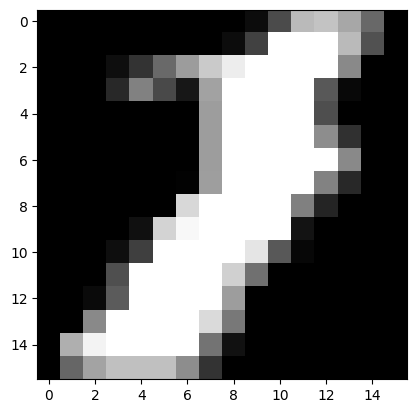

Klassifiziert als: [[1.]]


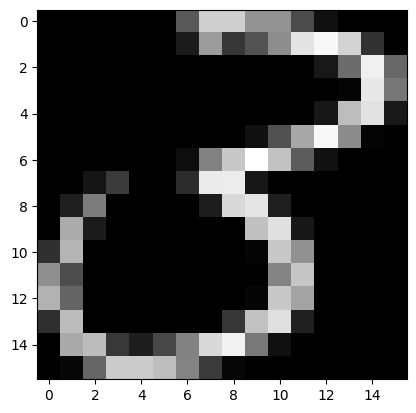

Klassifiziert als: [[3.]]


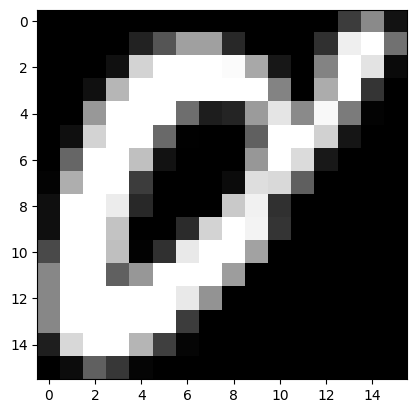

Klassifiziert als: [[7.]]


In [13]:
indices = [0,200,978]

# TODO
print(testX[0,:].shape)

for i in indices:
    plt.imshow(testX[i,:].reshape(16,16).transpose(),cmap='gray')
    plt.show()
    predY = kNN(trainX, trainY, testX[i,:], 1)
    print(f"Klassifiziert als: {predY}")
    


6.) Wir haben einen ersten Klassifikator umgesetzt, der auf Bildern Ziffern erkennen kann! Nun wollen wir aber wissen, wie gut er tatsächlich ist. Dazu reicht es nicht, nur Einzelbilder zu betrachten.

Zunächst nehmen wir aber noch eine Modifikation vor und verwenden eine deutlich effizientere Euklidische Distanzberechnungsfunktion, die eine der drei for Schleifen durch Vektorisierung ersetzt. 

Die Idee dahinter: Vom in der ersten Schleife ausgewählte Sample wird jedes in der zweiten Schleife ausgewählte Sample abgezogen und die Distanz quadriert. Durch Vektorisieren dieser Berechnung können wir uns diese zweite Schleife sparen. Implementieren Sie diese Funktion!
Hinweis: Nutzen Sie die Funktion tile, um das in der ersten Schleife ausgewählte Sample zu replizieren. 


In [14]:
# TODO
def euclidean_distance_1loop(data1: np.array, data2: np.array):
    # dimensions
    data1 = np.atleast_2d(data1)
    data2 = np.atleast_2d(data2)
    [num_samples1, p] = data1.shape
    [num_samples2, p] = data2.shape

    distances = np.zeros((num_samples1, num_samples2)) # initialize with zeros

    for i in range (0, num_samples1):
        # replicate training example (i-th row of data1) num_samples2 times such that
        # the size of the resulting matrix matches the size of data2
        replicated_row1 = np.tile(data1[i, ], (num_samples2, 1))
        # compute the distances of the samples in data2 from the i-th sample in data1 and element-wise square the results
        distance_squared = np.square(replicated_row1 - data2)
        # sum up the results per row
        sum_of_squares = np.sum(distance_squared, axis=1)
        # take the square root and transpose the result
        distances[i, :] = np.transpose( np.sqrt( sum_of_squares ) )
    return distances

Testen Sie diese Funktion auf den obigen Daten:

In [15]:
data1 = np.array([[1, 0], [0, 1], [1, 1]])
data2 = np.array([[1, 0], [0, 1]])

distances2 = euclidean_distance(data1, data2)
distances1 = euclidean_distance_1loop(data1, data2)

print(distances2)
print(distances1)

[[0.         1.41421356]
 [1.41421356 0.        ]
 [1.         1.        ]]
[[0.         1.41421356]
 [1.41421356 0.        ]
 [1.         1.        ]]


Prüfen Sie nun auf Gleichheit bei den Trainingsdaten und vergleichen Sie die Laufzeit:
Hinweis: Das kann ein paar Minuten dauern!

In [16]:
import time

t = time.time()
distances2 = euclidean_distance(trainX, testX)
elapsed = time.time() - t
print(f'Elapsed time with 2 loops: {elapsed}s')

t = time.time()
distances1 = euclidean_distance_1loop(trainX, testX)
elapsed = time.time() - t
print(f'Elapsed time with 1 loop:  {elapsed}s')

print(f'Maximum deviation between method with 2 loops and method with 1 loop:  {np.max(distances2-distances1)}')


Elapsed time with 2 loops: 79.81498074531555s
Elapsed time with 1 loop:  32.49830174446106s
Maximum deviation between method with 2 loops and method with 1 loop:  0.0


Es ist sogar möglich, auf zwei der drei Schleifen zu verzichten und so die Euklidische Distanzberechnung noch effizienter zu machen. Dazu nutzen wir die Binomische Formel (a-b)² = a² -2ab + b²:

Hinweis: Diese Method überschreibt obige Methode, da wir sie künftig im kNN benutzen wollen.

In [20]:
def euclidean_distance(data1: np.array, data2: np.array):
    # dimensions
    data1 = np.atleast_2d(data1)
    data2 = np.atleast_2d(data2)
    [num_samples1, p] = data1.shape
    [num_samples2, p] = data2.shape

    # Euclidean distance: sqrt ( (a-b)^2 )
    # calculate x'*x for each training example x (i.e. for each row of data1
    # respectively data2), results in num_samples1x1 respectively num_samples2x1 matrix
    check = np.square(data1)
    data1_squared = np.sum(np.square(data1), axis=1) # has size num_samples1 x 1
    data2_squared = np.sum(np.square(data2), axis=1) # has size num_samples2 x 1
    data1_squared = data1_squared.reshape([data1_squared.shape[0], 1]) # avoid that dimensions are dropped
    data2_squared = data2_squared.reshape([data2_squared.shape[0], 1])

    # Euclidean distance: sqrt ( (a-b)^2 )
    # Use the binomial formula: (a - b) ^ 2 = a ^ 2 - 2ab + b ^ 2!
    a_squared = np.tile(data1_squared, (1, num_samples2)) # replicate data1_squared along cols (num_samples2 repeats) => num_samples1 x num_samples2
    b_squared = np.tile(np.transpose(data2_squared), (num_samples1, 1)) # replicate transposed data2_squared along rows (num_samples1 repeats) => num_samples1 x num_samples2
    mixed_term = 2* data1.dot(np.transpose(data2))
    distances = np.sqrt( a_squared - mixed_term + b_squared )
    return distances

Diese Methode ist deutlich effizienter:

In [27]:
t = time.time()
distances0 = euclidean_distance(trainX, testX)
elapsed = time.time() - t
print(f'Elapsed time with 0 loops: {elapsed}s')

print(f'Maximum deviation between method with 2 loops and method with 0 loops: {np.max(distances2-distances0)}')


Elapsed time with 0 loops: 0.28523755073547363s
Maximum deviation between method with 2 loops and method with 0 loops: 1.9095836023552692e-14


Wenden Sie nun den kNN-Klassifikator auf die gesamten USPS Daten an (k=1, k=2, k=3). Verwenden Sie trainX und trainY als Trainings- und testX als Testdaten. 
Vergleichen Sie die Klassifikationsergebnisse mit den bekannten, korrekten Labels (testY) und berechnen Sie jeweils den Anteil der korrekten Klassifikationsergebnisse.

In [51]:
# todo
for k in [1,2,3]:
    predictedY = kNN(trainX, trainY, testX, k)
    accuracy = np.sum(predictedY.flatten()==testY.flatten())/testY.shape[0]
    print(f"Accuracy for k={k}: {accuracy}")

Accuracy for k=1: 0.947
Accuracy for k=2: 0.93
Accuracy for k=3: 0.944


7.) Diskutieren Sie die Ergebnisse mit Ihren Mitstudierenden!

In einigen Fällen gibt es unter Umständen keine klare Mehrheit für eine Klasse - möglicherweise sind unter den k nächsten Nachbarn ähnlich viele 3en wie 9en. Machen Sie einen Vorschlag, was in diesem Fall hilfreich für den Anwender sein könnte!

8.) BONUS: Betrachten Sie folgendes (unkommentiertes) Codefragment und beschreiben Sie dessen Wirkung:

In [24]:
from scipy.ndimage import gaussian_filter

def preprocessData(dataIn):
    dataOut = np.zeros(dataIn.shape)
    len = np.sqrt(dataIn.shape[1]).astype(np.int64)
    for i in range(0, dataIn.shape[0]):
        img = np.reshape(dataIn[i, :], [len, len]);
        img_filtered = gaussian_filter(img, sigma=1)
        dataOut[i, :] = np.reshape(img_filtered, [1, len*len]);       
    return dataOut

Führen Sie folgende Codezeilen aus und bewerten Sie erneut die Güte des Klassifikators (siehe Teil 6.). Was stellen Sie fest? Wie erklären Sie sich den Unterschied?

Accuracy for k=1: 0.971
Accuracy for k=2: 0.968
Accuracy for k=3: 0.97


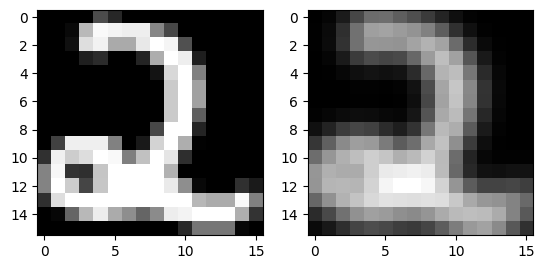

In [25]:
trainX_processed = preprocessData(trainX)
testX_processed  = preprocessData(testX)

fig, axs = plt.subplots(1,2)
axs[0].imshow(trainX[1000,:].reshape(16,16).transpose(),cmap='gray')
axs[1].imshow(trainX_processed[1000,:].reshape(16,16).transpose(),cmap='gray')

# Accuracy
for i in [1,2,3]:
    predictedY = kNN(trainX_processed, trainY, testX_processed, i)
    accuracy = np.sum(predictedY.flatten()==testY.flatten())/testY.shape[0]
    print(f"Accuracy for k={i}: {accuracy}")